<a href="https://colab.research.google.com/github/dgylayse/AkademiQ_DataScience/blob/main/AkademiQ_Data_Science_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo -q # satış pazarlama veri seti

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [7]:
bank_marketing = fetch_ucirepo(id=222)

x = bank_marketing.data.features.copy()
y = bank_marketing.data.targets.copy() # y yani target müşteri abone olacak mı olmayacak mı

print("X boyutları:", x.shape)
print("Y boyutları:", y.shape)

display(x.head())
display(y.head())

X boyutları: (45211, 16)
Y boyutları: (45211, 1)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


,y
0,no
1,no
2,no
3,no
4,no


**Hedef Değişken Hazırlama**

In [8]:
target_col = y.columns[0]

y = y[target_col].map({
    "yes":1,
    "no": 0
})

print(y.value_counts())
print(y.value_counts(normalize=True))


y
0    39922
1     5289
Name: count, dtype: int64
y
0    0.883015
1    0.116985
Name: proportion, dtype: float64


**Sütun Tiplerini Ayırma**

In [10]:
numeric_features = x.select_dtypes(include=["int64","float64"]).columns.tolist()

categorical_features = x.select_dtypes(include=["object","category"]).columns.tolist()

print("Sayısal sütunlar")
print(numeric_features)

print("Kategorik sütunlar")
print(categorical_features)

Sayısal sütunlar
['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
Kategorik sütunlar
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


**Train Test Bölme**

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify= y)

print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (36168, 16)
Test: (9043, 16)


**Ön İşleme Pipeline'ı**

In [18]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_features_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_features_pipeline, categorical_features)
])




# Decision Tree Model Kurma

In [21]:
from sklearn import model_selection
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", decision_tree_model)
])

model_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'balance',
                                                   'day_of_week', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=50,
                                        random_state=42))])

# Tahmin ve Olasılık Üretme

In [28]:
y_pred = model_pipeline.predict(x_test)
y_proba = model_pipeline.predict_proba(x_test)[:,1]

print("Classification report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Classification report:
              precision    recall  f1-score   support

           0       0.97      0.76      0.86      7985
           1       0.32      0.84      0.46      1058

    accuracy                           0.77      9043
   macro avg       0.65      0.80      0.66      9043
weighted avg       0.90      0.77      0.81      9043

ROC-AUC: 0.8755355327155241


Precision = TP / (TP + FP) Kesinlik

Recall = TP  / (TP + FN)

f1 = 2 . ( (precision . recall) / (precision + recall) )

# Conf Matris

In [31]:
cm = confusion_matrix(y_test, y_pred)

cd_df = pd.DataFrame(cm, index=["Gerçek: No", "Gerçek: Yes"], columns=["Tahmin: No", "Tahmin: Yes"])
display(cd_df)

,Tahmin: No,Tahmin: Yes
Gerçek: No,6095,1890
Gerçek: Yes,172,886


# Karar Ağacı

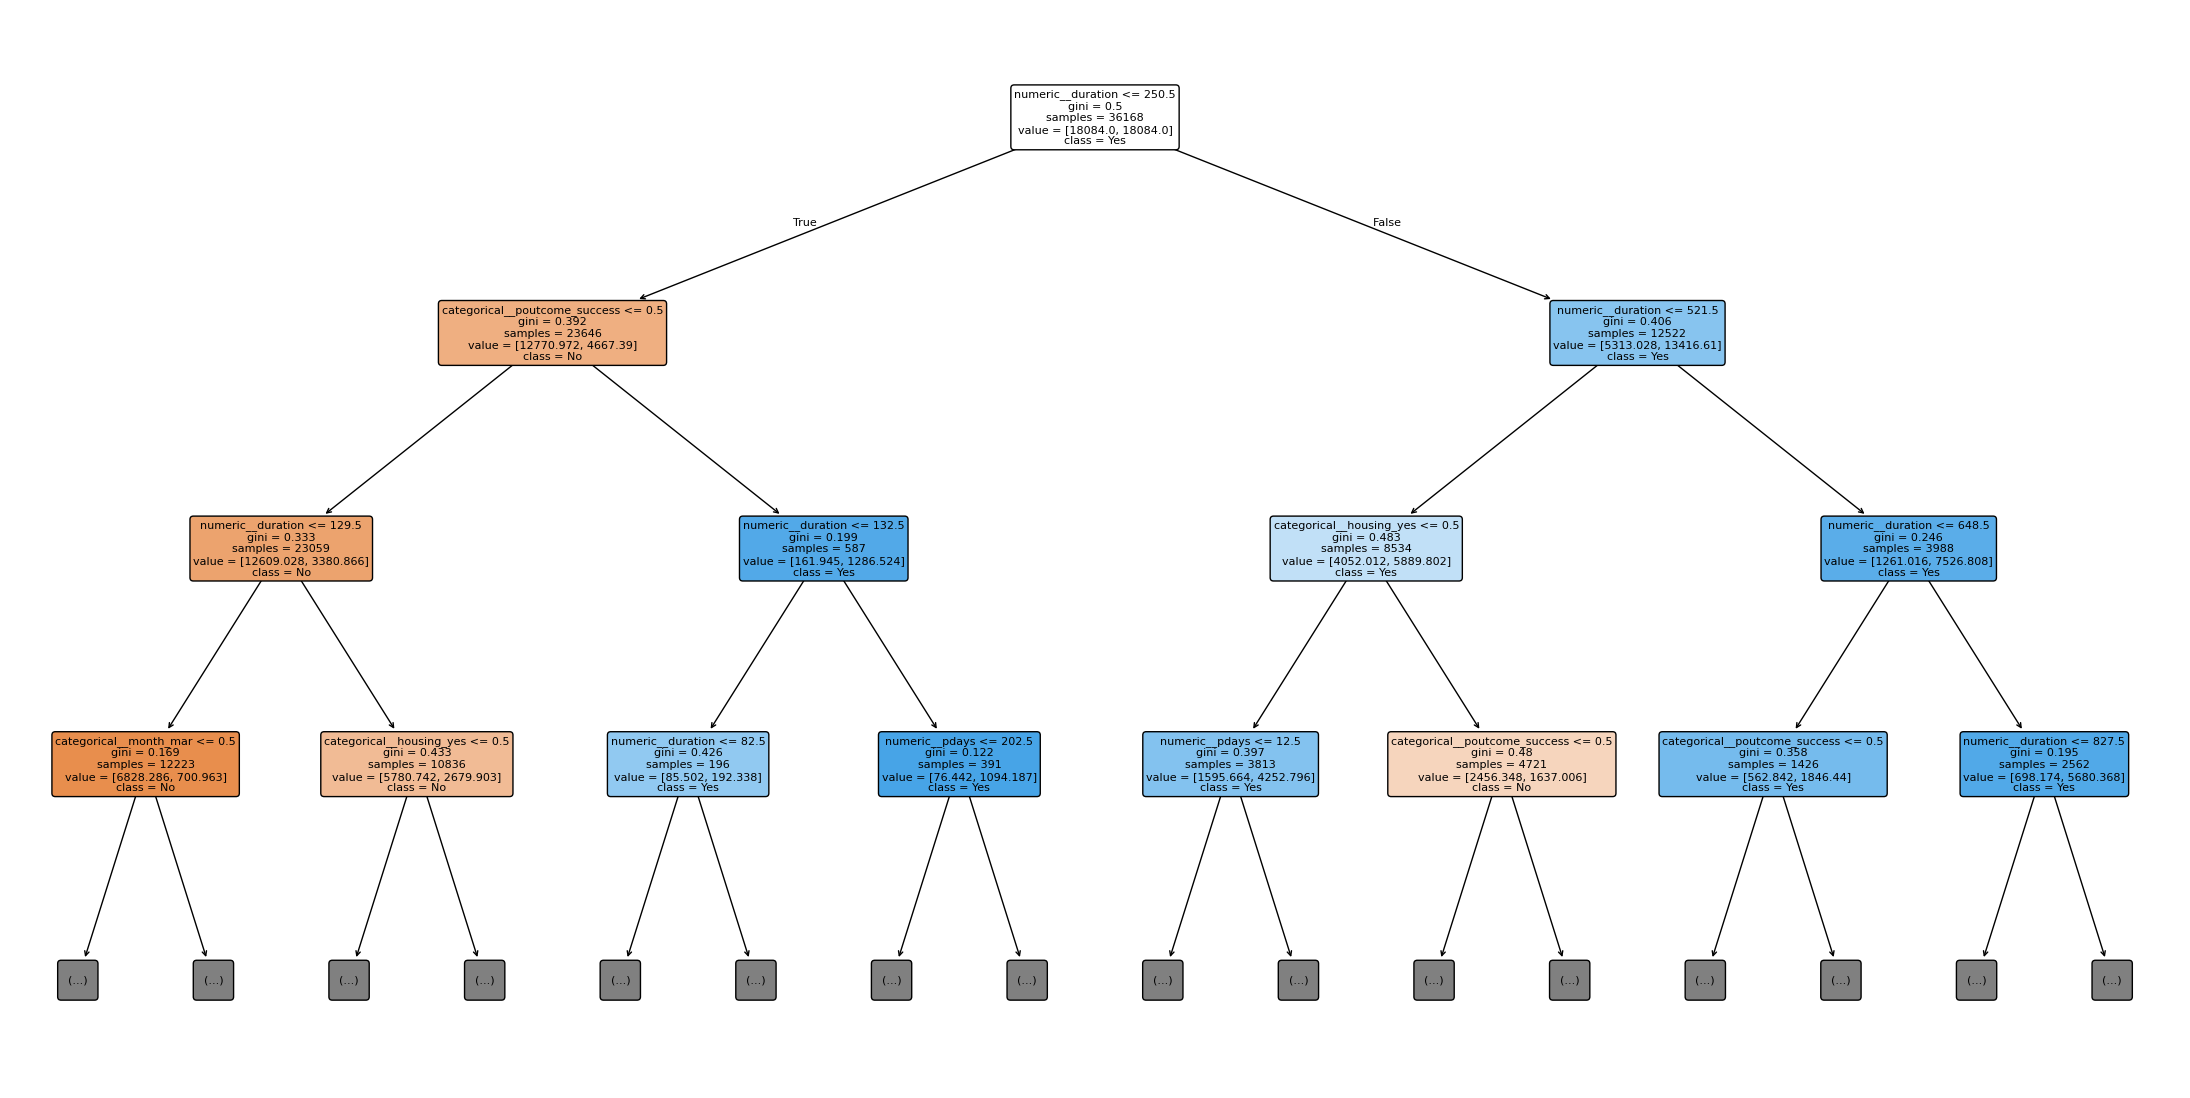

In [32]:
from pandas.io import feather_format
trained_tree = model_pipeline.named_steps["model"]

feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(28,14))

plot_tree(trained_tree, feature_names=feature_names, class_names=["No", "Yes"], filled=True, rounded= True, fontsize=8, max_depth=3)

plt.show()